In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

# Suppress TF hardware logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("TensorFlow Version:", tf.__version__)
print("Running setup complete!")

TensorFlow Version: 2.22.0-rc0
Running setup complete!


In [4]:
train_dir = '../data/training'
test_dir = '../data/testing'
batch_size = 32
img_size = (224, 224)

# 1. Load Training Dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# 2. Load Validation Dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# 3. Load Testing Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found ({num_classes}):", class_names)

# Performance Tuning for CPU Execution
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes found (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
model2 = models.Sequential([
    # Input Scaling
    layers.Rescaling(1./255, input_shape=(img_size[0], img_size[1], 3)),
    
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model2.summary()

c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,564 (98.37 MB)

 Trainable params: 25,785,604 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

epochs = 25
history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/25


c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.7650 - loss: 1.8245 - val_accuracy: 0.2482 - val_loss: 44.5584
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.8527 - loss: 1.4297 - val_accuracy: 0.2768 - val_loss: 18.5136
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8725 - loss: 1.2991 - val_accuracy: 0.6402 - val_loss: 2.2583
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.8768 - loss: 1.5478 - val_accuracy: 0.8723 - val_loss: 1.4874
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9103 - loss: 1.3335 - val_accuracy: 0.6946 - val_loss: 1.8302
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9127 - loss: 1.2635 - val_accuracy: 0.4857 - val_loss: 7.8268
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9069 - loss: 1.5832 - val_accuracy: 0.9214 - val_loss: 1.4848
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.9315 - loss: 1.3060 - val_accuracy: 0.6

In [8]:
# Unseen Test Dataset එක මත Evaluation එක
test_loss, test_acc = model2.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.8269 - loss: 2.0466

Final Test Accuracy: 0.8269
Final Test Loss: 2.0466


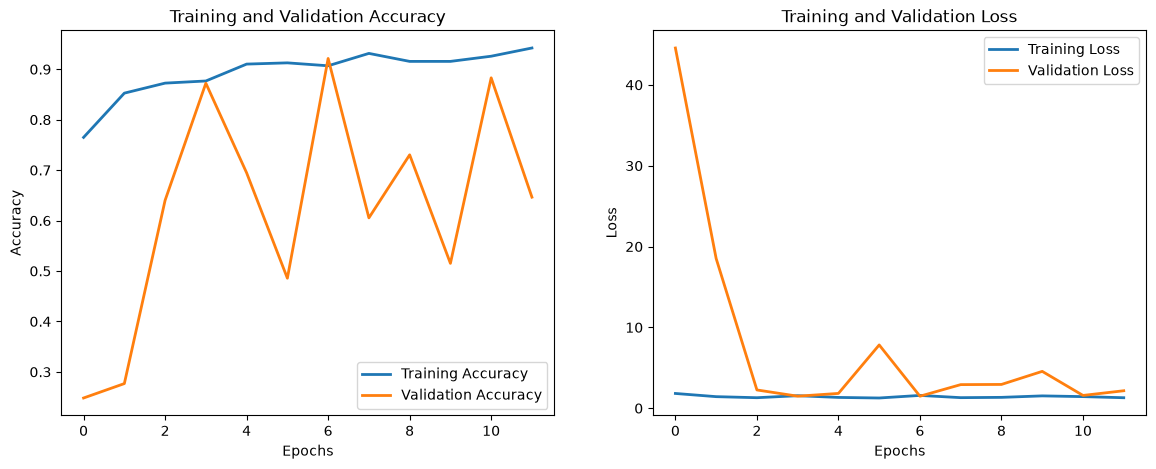

In [9]:
import matplotlib.pyplot as plt

# Retrieve loss and accuracy from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.91      0.66      0.76       400
  meningioma       0.81      0.69      0.75       400
     notumor       0.73      1.00      0.84       400
   pituitary       0.91      0.96      0.93       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.82      1600
weighted avg       0.84      0.83      0.82      1600



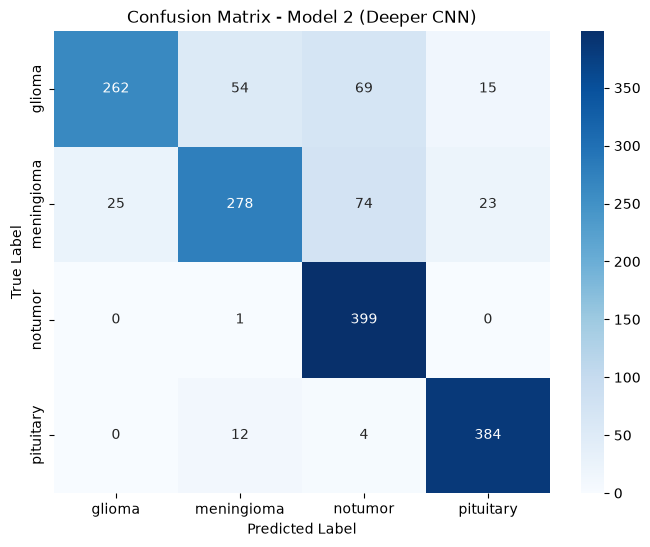

In [10]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get true labels and predictions for test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print Classification Report (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model 2 (Deeper CNN)')
plt.show()


In [11]:
# Save the trained model in Native Keras Format (.keras)
model2.save('model2_deeper_cnn.keras')
print("Model 2 successfully saved as model2_deeper_cnn.keras!")


Model 2 successfully saved as model2_deeper_cnn.keras!
